# **PPAAR-GAMMA Ligand Embedding Analysis**

**Purpose:** Visualize and analyze embeddings from direct ligand_encoder_runner

**Data:** Global embeddings, per-atom embeddings, hypergraph attention

**Classes:** Agonist / Antagonist / Decoy

----

- Author: Aaryesh Deshpande
- Date: October 28, 2025

## Setup & Data Loading

In [78]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import entropy
from scipy.spatial.distance import pdist
from umap import UMAP

warnings.filterwarnings('ignore')

In [79]:
# Configuration
BASE_DIR = Path("../Output/rnd_encodings/ligands/val")  # Adjust path as needed
META_PATH = BASE_DIR / "encodings_metadata.json"
GLOBAL_DIR = BASE_DIR / "global"
ATOMS_DIR = BASE_DIR / "atoms"
LABELS_CSV = Path("../Data/meta/ligands_clean.csv")  # Adjust path as needed

# Visualization settings
RANDOM_SEED = 16
FIGSIZE_SMALL = (8, 6)
FIGSIZE_MEDIUM = (12, 8)
FIGSIZE_LARGE = (15, 10)
DPI = 100

# Class colors
CLASS_COLORS = {
    'agonist': '#2ecc71',     # Green
    'antagonist': '#e74c3c',  # Red
    'decoy': '#95a5a6'        # Gray
}

CLASS_MARKERS = {
    'agonist': 'o',
    'antagonist': 's',
    'decoy': '^'
}

print(f"Base directory: {BASE_DIR}")
print(f"Global embeddings: {GLOBAL_DIR}")
print(f"Atom embeddings: {ATOMS_DIR}")
print(f"Labels CSV: {LABELS_CSV}")

Base directory: ../Output/rnd_encodings/ligands/val
Global embeddings: ../Output/rnd_encodings/ligands/val/global
Atom embeddings: ../Output/rnd_encodings/ligands/val/atoms
Labels CSV: ../Data/meta/ligands_clean.csv


In [80]:
# Load metadata
if META_PATH.exists():
    with open(META_PATH, 'r') as f:
        metadata = json.load(f)

    print("Metadata:")
    if 'model_config' in metadata:
        print("\nModel config:")
        for k, v in metadata['model_config'].items():
            print(f"      {k}: {v}")
else:
    print("No metadata file found")
    metadata = {}

Metadata:

Model config:
      d_node: 44
      d_edge: 6
      d_hyper_feat: 15
      d_model: 256
      n_gnn_layers: 3
      n_hyper_layers: 2


In [81]:
# Load labels from CSV
if LABELS_CSV.exists():
    df_labels = pd.read_csv(LABELS_CSV)

    print("- Labels loaded:")
    print(f"- Shape: {df_labels.shape}")
    print(f"- Columns: {list(df_labels.columns)}")
    print("\nSample:")
    print(df_labels.head())

    # Create unified label
    def get_class_label(row):
        if row.get('is_decoy', False) or str(row.get('class_label', '')).lower() == 'decoy':
            return 'decoy'
        label = str(row.get('class_label', '')).lower()
        if 'antagonist' in label:
            return 'antagonist'
        elif 'agonist' in label:
            return 'agonist'
        else:
            return 'unknown'

    df_labels['unified_label'] = df_labels.apply(get_class_label, axis=1)

    print("\nClass distribution:")
    class_counts = df_labels['unified_label'].value_counts()
    for cls, count in class_counts.items():
        pct = 100 * count / len(df_labels)
        print(f"- {cls}: {count} ({pct:.1f}%)")

    # Create lookup dictionary
    label_dict = dict(zip(df_labels['ligand_id'], df_labels['unified_label']))

else:
    print("Labels CSV not found - will proceed without labels")
    df_labels = None
    label_dict = {}

- Labels loaded:
- Shape: (49574, 5)
- Columns: ['ligand_id', 'smiles', 'mol2_path', 'class_label', 'is_decoy']

Sample:
       ligand_id                                             smiles  \
0   CHEMBL107367  Cc1oc(nc1CCOc2ccc(C[C@H](Nc3ccccc3C(=O)c4ccccc...   
1   CHEMBL107991  CCCc1cc(Oc2ccc(OC)cc2)ccc1OCCCOc3ccc4CCC(CC)(O...   
2  CHEMBL1087339    Cc1ccccc1OC(=O)C2C(C(C2c3ccccc3)C(=O)O)c4ccccc4   
3  CHEMBL1087460  Cc1cccc(OC(=O)C2C(C(C2c3ccccc3)C(=O)O)c4ccccc4)c1   
4  CHEMBL1087588      CC(C)CCOC(=O)C1C(C(C1c2ccccc2)C(=O)O)c3ccccc3   

                                           mol2_path class_label  is_decoy  
0  /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...     agonist         0  
1  /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...     agonist         0  
2  /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...     agonist         0  
3  /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...     agonist         0  
4  /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...     agonist   

In [82]:
# Load global embeddings
global_files = sorted(GLOBAL_DIR.glob("*.pt"))
print(f"Loading {len(global_files)} global embeddings...")

ligand_ids = []
embeddings = []
labels = []

for fpath in tqdm(global_files, desc="Loading"):
    lig_id = fpath.stem.replace("_global", "")

    # Load embedding
    emb = torch.load(fpath, map_location='cpu')
    if isinstance(emb, torch.Tensor):
        emb = emb.detach().cpu().numpy()
    if emb.ndim > 1:
        emb = emb.squeeze()

    ligand_ids.append(lig_id)
    embeddings.append(emb)
    labels.append(label_dict.get(lig_id, 'unknown'))

# Convert to arrays
embeddings = np.array(embeddings)
ligand_ids = np.array(ligand_ids)
labels = np.array(labels)

print(f"\nLoaded {len(embeddings)} embeddings")
print(f"- Shape: {embeddings.shape}")
print(f"- Dtype: {embeddings.dtype}")
print("\nLabel distribution in loaded data:")
unique_labels, counts = np.unique(labels, return_counts=True)
for lbl, cnt in zip(unique_labels, counts):
    pct = 100 * cnt / len(labels)
    print(f"- {lbl}: {cnt} ({pct:.1f}%)")

Loading 4957 global embeddings...


Loading:   0%|          | 0/4957 [00:00<?, ?it/s]


Loaded 4957 embeddings
- Shape: (4957, 256)
- Dtype: float32

Label distribution in loaded data:
- agonist: 182 (3.7%)
- antagonist: 1 (0.0%)
- decoy: 4774 (96.3%)


Embedding Statistics:
- Mean norm: 6.2603
- Std norm: 0.1014
- Min value: -1.1730
- Max value: 1.3304
- Mean value: 0.0036
- Std value: 0.3913

No NaN or Inf values


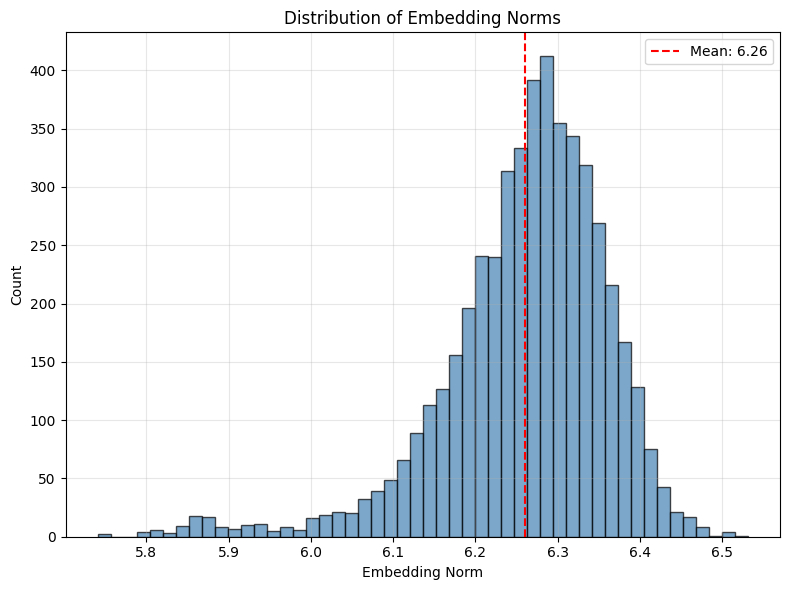

In [83]:
# Basic statistics
print("Embedding Statistics:")
print(f"- Mean norm: {np.linalg.norm(embeddings, axis=1).mean():.4f}")
print(f"- Std norm: {np.linalg.norm(embeddings, axis=1).std():.4f}")
print(f"- Min value: {embeddings.min():.4f}")
print(f"- Max value: {embeddings.max():.4f}")
print(f"- Mean value: {embeddings.mean():.4f}")
print(f"- Std value: {embeddings.std():.4f}")

# Check for NaN/Inf
n_nan = np.isnan(embeddings).sum()
n_inf = np.isinf(embeddings).sum()
if n_nan > 0 or n_inf > 0:
    print(f"\nWarning: {n_nan} NaN values, {n_inf} Inf values")
else:
    print("\nNo NaN or Inf values")

# Norm distribution
norms = np.linalg.norm(embeddings, axis=1)
plt.figure(figsize=FIGSIZE_SMALL, dpi=DPI)
plt.hist(norms, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(norms.mean(), color='red', linestyle='--', label=f'Mean: {norms.mean():.2f}')
plt.xlabel('Embedding Norm')
plt.ylabel('Count')
plt.title('Distribution of Embedding Norms')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## **2. Global Embedding Analysis**

### 2.1 Dimensionality Reduction

   Components for 95% variance: 13
   Components for 99% variance: 30


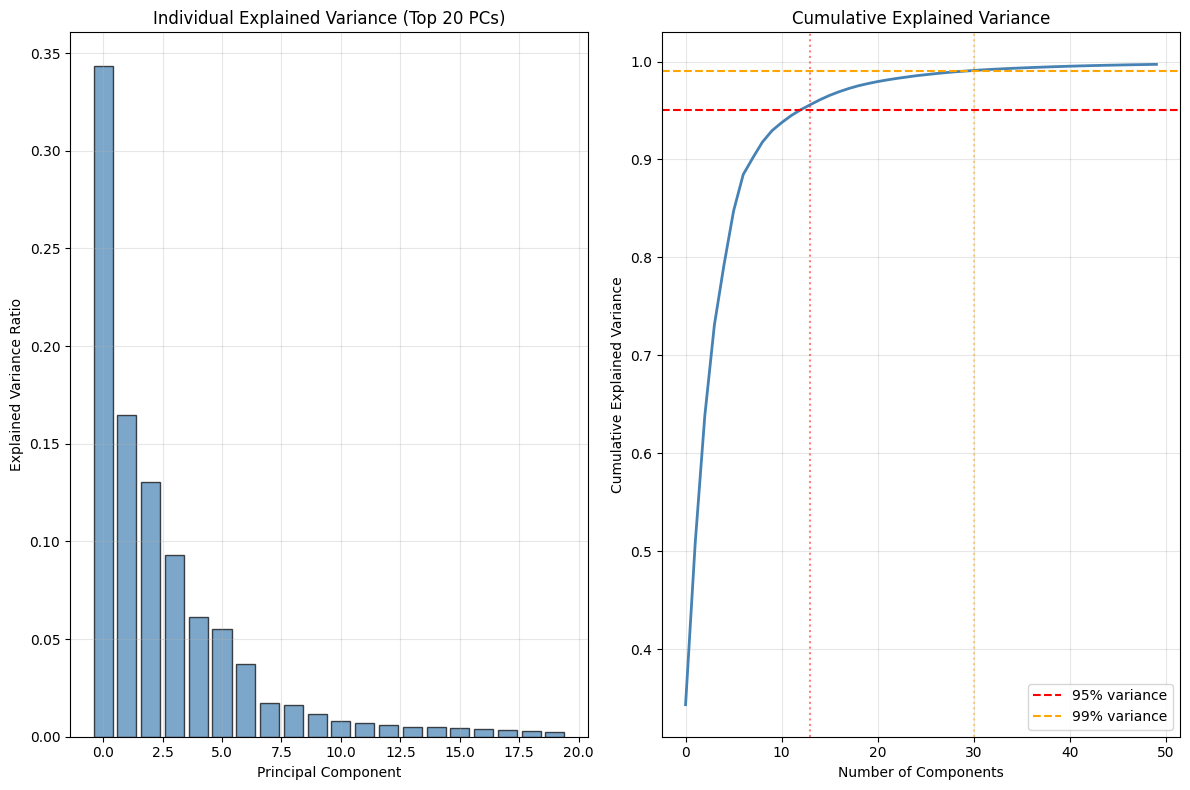

In [84]:
# PCA Analysis
pca = PCA(n_components=min(50, embeddings.shape[1]), random_state=RANDOM_SEED)
embeddings_pca = pca.fit_transform(embeddings)

# Explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1
n_99 = np.argmax(cum_var >= 0.99) + 1

print(f"   Components for 95% variance: {n_95}")
print(f"   Components for 99% variance: {n_99}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_MEDIUM, dpi=DPI)

# Individual variance
axes[0].bar(range(len(pca.explained_variance_ratio_[:20])),
            pca.explained_variance_ratio_[:20],
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance (Top 20 PCs)')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(cum_var[:50], linewidth=2, color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% variance')
axes[1].axhline(0.99, color='orange', linestyle='--', label='99% variance')
axes[1].axvline(n_95, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(n_99, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Keep first 2-3 PCs for visualization
pca_2d = embeddings_pca[:, :2]
pca_3d = embeddings_pca[:, :3]

In [85]:
# t-SNE Analysis
pca_50 = embeddings_pca[:, :min(50, embeddings_pca.shape[1])]

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=RANDOM_SEED,
    verbose=0
).fit_transform(pca_50)

In [86]:
# umap
umap_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_SEED
).fit_transform(pca_50)

umap_3d = UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_SEED
).fit_transform(pca_50)

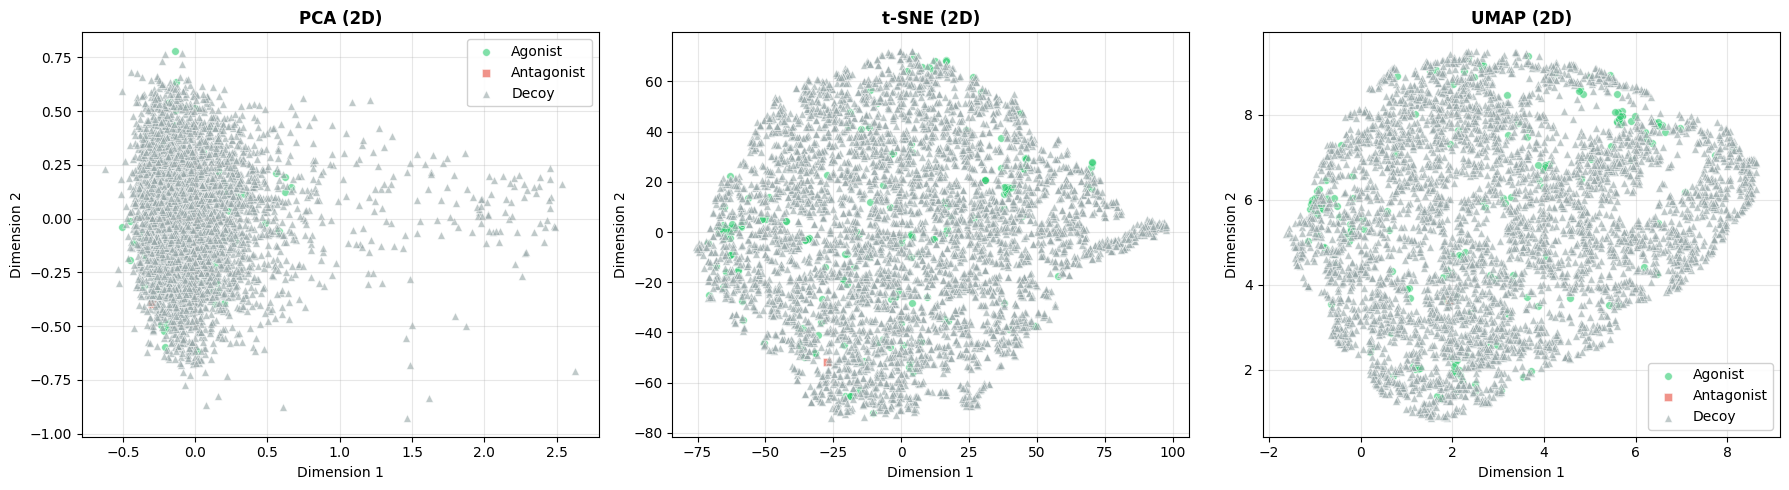

In [87]:
# Plot 2D comparisons
def plot_embedding_2d(coords, labels, title, ax, legend=True):
    """Helper to plot 2D embeddings with class colors."""
    for cls in np.unique(labels):
        if cls == 'unknown':
            continue
        mask = labels == cls
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=CLASS_COLORS.get(cls, '#999999'),
            label=cls.capitalize(),
            alpha=0.6,
            s=30,
            marker=CLASS_MARKERS.get(cls, 'o'),
            edgecolors='white',
            linewidths=0.5
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    if legend:
        ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

n_plots = 3
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5), dpi=DPI)
if n_plots == 2:
    axes = [axes[0], axes[1]]

plot_embedding_2d(pca_2d, labels, 'PCA (2D)', axes[0])
plot_embedding_2d(tsne_2d, labels, 't-SNE (2D)', axes[1], legend=(n_plots==2))
plot_embedding_2d(umap_2d, labels, 'UMAP (2D)', axes[2])

plt.tight_layout()
plt.show()

### 2.2 Cluster Quality Metrics

Cluster Quality Metrics:

1. Silhouette Score (higher is better, range [-1, 1]):
Original:
- Silhouette: -0.0945
- Davies-Bouldin: 3.6442 (lower is better)
- Calinski-Harabasz: 10.10 (higher is better)
PCA-2D:
- Silhouette: -0.2026
- Davies-Bouldin: 3.8532 (lower is better)
- Calinski-Harabasz: 6.16 (higher is better)
t-SNE:
- Silhouette: -0.1395
- Davies-Bouldin: 6.1613 (lower is better)
- Calinski-Harabasz: 4.59 (higher is better)
UMAP:
- Silhouette: -0.2241
- Davies-Bouldin: 7.6180 (lower is better)
- Calinski-Harabasz: 3.04 (higher is better)


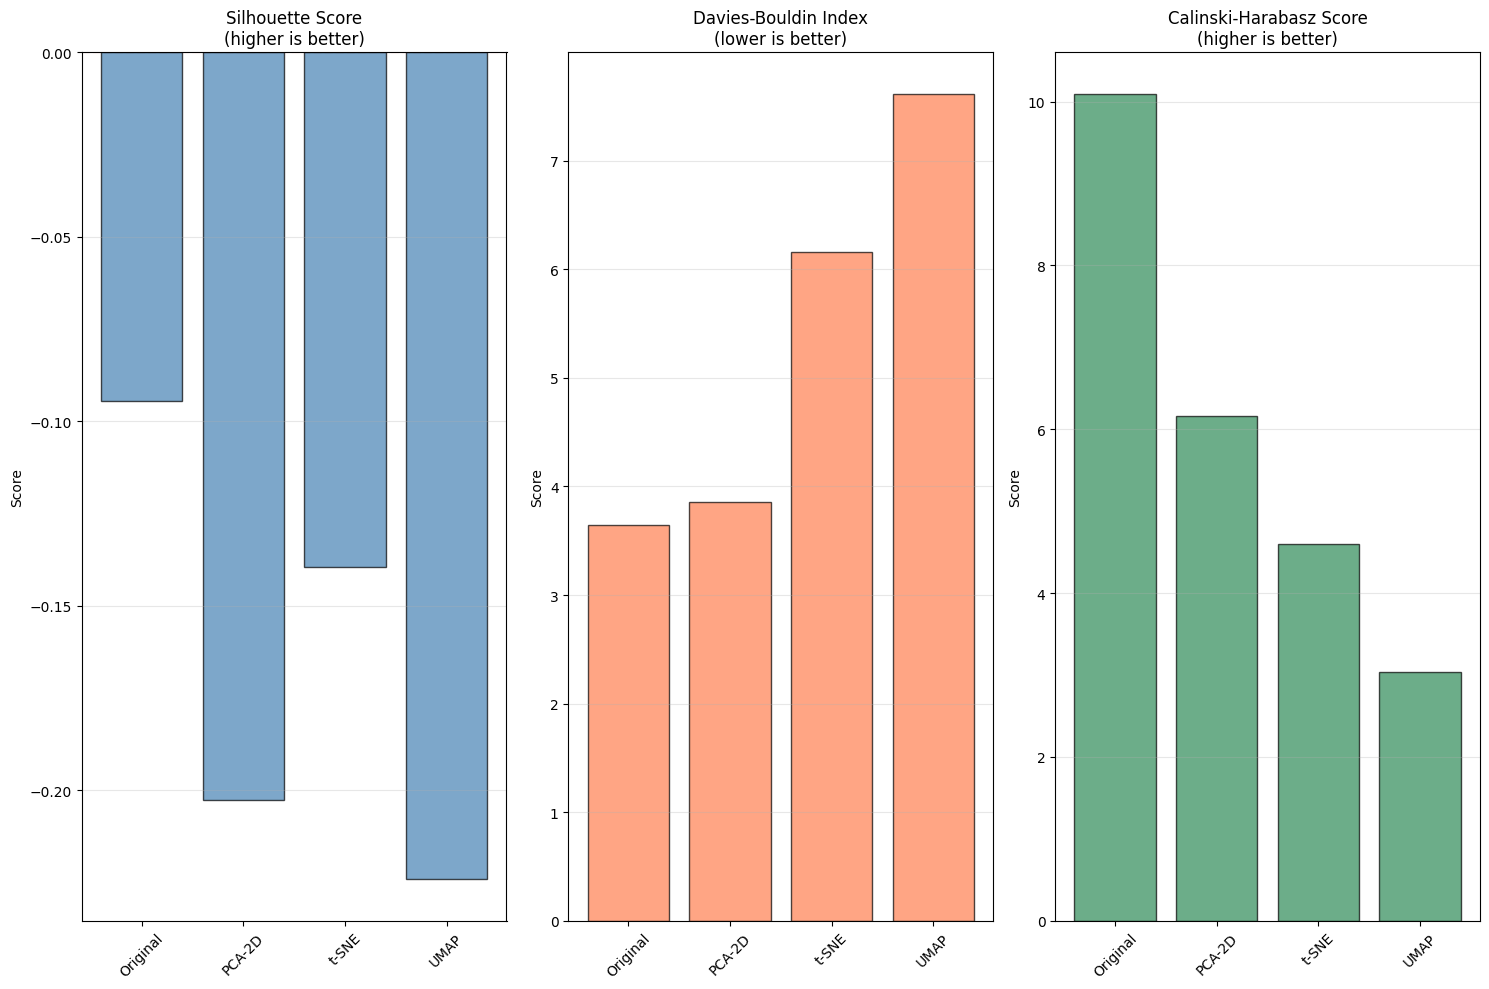

In [88]:
# Compute cluster quality metrics
# Filter out 'unknown' labels
valid_mask = labels != 'unknown'
if valid_mask.sum() < 2:
    print("Not enough labeled data for cluster metrics")
else:
    labels_numeric = pd.Categorical(labels[valid_mask]).codes

    print("Cluster Quality Metrics:")
    print("\n1. Silhouette Score (higher is better, range [-1, 1]):")

    metrics_data = []

    for name, data in [
        ('Original', embeddings[valid_mask]),
        ('PCA-2D', pca_2d[valid_mask]),
        ('t-SNE', tsne_2d[valid_mask]),
        ('UMAP', umap_2d[valid_mask])
    ]:
        if data is None:
            continue

        sil = silhouette_score(data, labels_numeric, metric='euclidean')
        db = davies_bouldin_score(data, labels_numeric)
        ch = calinski_harabasz_score(data, labels_numeric)

        metrics_data.append({
            'Method': name,
            'Silhouette': sil,
            'Davies-Bouldin': db,
            'Calinski-Harabasz': ch
        })

        print(f"{name}:")
        print(f"- Silhouette: {sil:.4f}")
        print(f"- Davies-Bouldin: {db:.4f} (lower is better)")
        print(f"- Calinski-Harabasz: {ch:.2f} (higher is better)")

    df_metrics = pd.DataFrame(metrics_data)

    # Plot comparison
    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_LARGE, dpi=DPI)

    axes[0].bar(df_metrics['Method'], df_metrics['Silhouette'],
                color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_title('Silhouette Score\n(higher is better)')
    axes[0].set_ylabel('Score')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

    axes[1].bar(df_metrics['Method'], df_metrics['Davies-Bouldin'],
                color='coral', alpha=0.7, edgecolor='black')
    axes[1].set_title('Davies-Bouldin Index\n(lower is better)')
    axes[1].set_ylabel('Score')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')

    axes[2].bar(df_metrics['Method'], df_metrics['Calinski-Harabasz'],
                color='seagreen', alpha=0.7, edgecolor='black')
    axes[2].set_title('Calinski-Harabasz Score\n(higher is better)')
    axes[2].set_ylabel('Score')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

### 2.3 Class Separation Analysis

   agonist <-> agonist: 0.9933
   agonist <-> antagonist: 0.9911
   agonist <-> decoy: 0.9906
   antagonist <-> antagonist: nan
   antagonist <-> decoy: 0.9894
   decoy <-> decoy: 0.9891

Centroid Distances (L2):
agonist <-> antagonist: 0.6973
agonist <-> decoy: 0.2150
antagonist <-> decoy: 0.6782


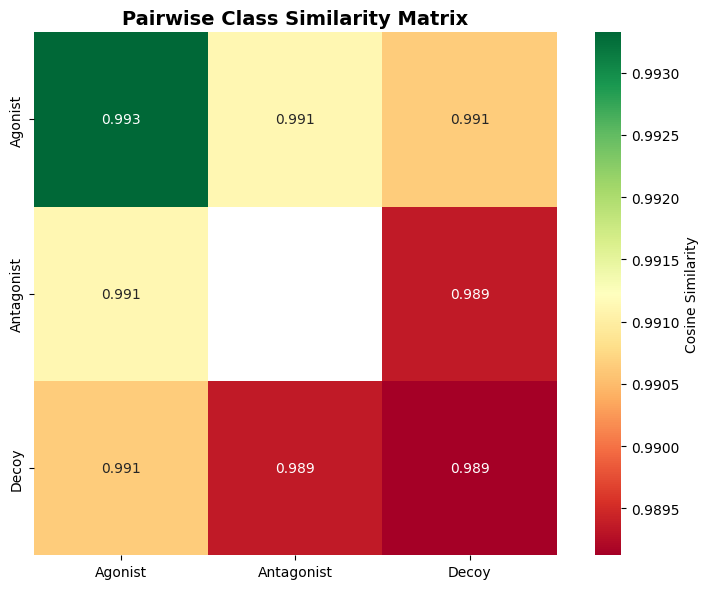

   Average within-class similarity: nan
   Average between-class similarity: 0.9904
   Separation ratio: nanx
Poor class separation


In [89]:
# Compute pairwise distances between classes
# Get class embeddings
class_embeddings = {}
for cls in ['agonist', 'antagonist', 'decoy']:
    mask = labels == cls
    if mask.sum() > 0:
        class_embeddings[cls] = embeddings[mask]

# Compute pairwise similarities
similarities = {}
for cls1 in class_embeddings:
    for cls2 in class_embeddings:
        if cls1 <= cls2:  # Avoid duplicates
            sim_matrix = cosine_similarity(
                class_embeddings[cls1],
                class_embeddings[cls2]
            )
            if cls1 == cls2:
                # Within-class: exclude diagonal
                mask = ~np.eye(len(sim_matrix), dtype=bool)
                sim = sim_matrix[mask].mean()
            else:
                # Between-class: all pairs
                sim = sim_matrix.mean()

            similarities[f"{cls1}-{cls2}"] = sim
            print(f"   {cls1} <-> {cls2}: {sim:.4f}")

# Compute class centroids
centroids = {}
for cls, embs in class_embeddings.items():
    centroids[cls] = embs.mean(axis=0)

# Centroid distances
print("\nCentroid Distances (L2):")
for cls1 in centroids:
    for cls2 in centroids:
        if cls1 < cls2:
            dist = np.linalg.norm(centroids[cls1] - centroids[cls2])
            print(f"{cls1} <-> {cls2}: {dist:.4f}")

# Visualization: similarity matrix
class_list = sorted(class_embeddings.keys())
n_classes = len(class_list)
sim_matrix_viz = np.zeros((n_classes, n_classes))

for i, cls1 in enumerate(class_list):
    for j, cls2 in enumerate(class_list):
        if i == j:
            # Within-class similarity
            key = f"{cls1}-{cls1}"
        elif i < j:
            key = f"{cls1}-{cls2}"
        else:
            key = f"{cls2}-{cls1}"
        sim_matrix_viz[i, j] = similarities.get(key, 0)

# Plot heatmap
plt.figure(figsize=(8, 6), dpi=DPI)
sns.heatmap(
    sim_matrix_viz,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    xticklabels=[c.capitalize() for c in class_list],
    yticklabels=[c.capitalize() for c in class_list],
    cbar_kws={'label': 'Cosine Similarity'},
    square=True
)
plt.title('Pairwise Class Similarity Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

within_class_sims = [similarities[f"{c}-{c}"] for c in class_list if f"{c}-{c}" in similarities]
between_class_sims = [v for k, v in similarities.items() if '-' in k and k.split('-')[0] != k.split('-')[1]]

if within_class_sims and between_class_sims:
    avg_within = np.mean(within_class_sims)
    avg_between = np.mean(between_class_sims)
    separation_ratio = avg_within / avg_between if avg_between > 0 else float('inf')

    print(f"   Average within-class similarity: {avg_within:.4f}")
    print(f"   Average between-class similarity: {avg_between:.4f}")
    print(f"   Separation ratio: {separation_ratio:.2f}x")

    if separation_ratio > 1.2:
        print("Good class separation!")
    elif separation_ratio > 1.0:
        print("Moderate class separation")
    else:
        print("Poor class separation")

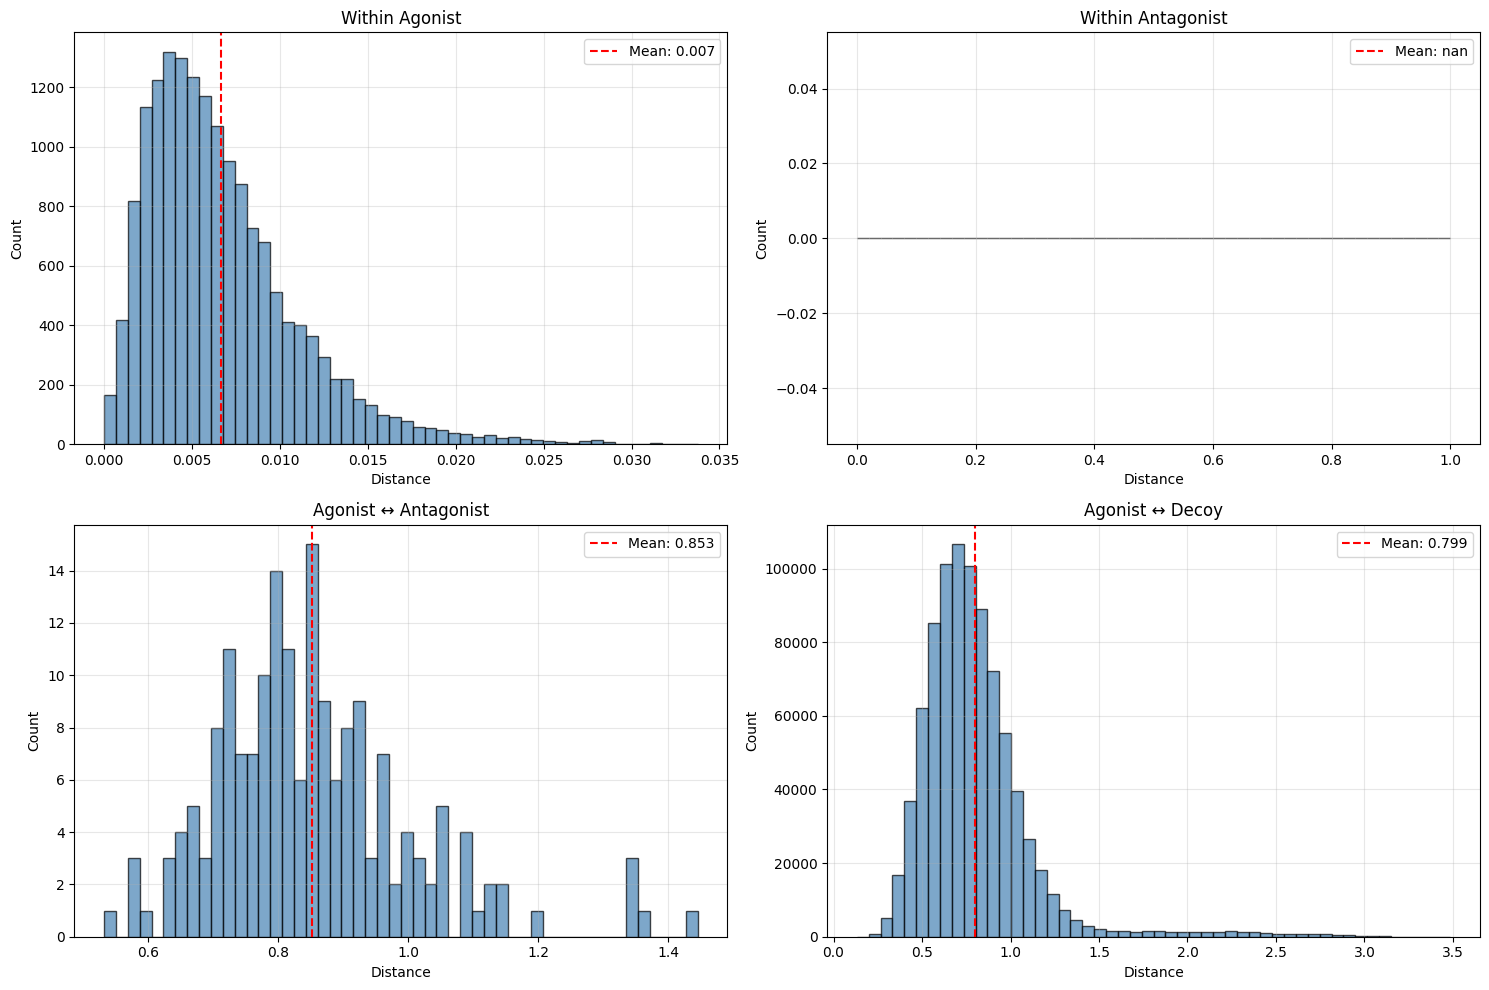

In [90]:
# Distance distributions
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE, dpi=DPI)
axes = axes.flatten()

for idx, (cls1, cls2) in enumerate([
    ('agonist', 'agonist'),
    ('antagonist', 'antagonist'),
    ('agonist', 'antagonist'),
    ('agonist', 'decoy')
]):
    if idx >= 4:
        break

    mask1 = labels == cls1
    mask2 = labels == cls2

    if mask1.sum() == 0 or mask2.sum() == 0:
        continue

    # Compute distances
    if cls1 == cls2:
        # Within-class
        dists = pdist(embeddings[mask1], metric='cosine')
        title = f"Within {cls1.capitalize()}"
    else:
        # Between-class
        emb1 = embeddings[mask1]
        emb2 = embeddings[mask2]
        dists = euclidean_distances(emb1, emb2).flatten()
        title = f"{cls1.capitalize()} ↔ {cls2.capitalize()}"

    # Plot histogram
    axes[idx].hist(dists, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axvline(dists.mean(), color='red', linestyle='--',
                     label=f'Mean: {dists.mean():.3f}')
    axes[idx].set_xlabel('Distance')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(title)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Per-Atom Embedding Analysis

In [91]:
# Check availability of atom embeddings
atom_files = sorted(ATOMS_DIR.glob("*_atoms.pt"))
print(f"Found {len(atom_files)} atom embedding files")

if len(atom_files) == 0:
    print("No atom embeddings found - skipping per-atom analysis")
else:
    # Select a few ligands for detailed inspection
    n_inspect = min(5, len(atom_files))

    # Try to get one from each class
    inspect_ids = []
    for cls in ['agonist', 'antagonist', 'decoy']:
        cls_ids = ligand_ids[labels == cls]
        if len(cls_ids) > 0:
            inspect_ids.append(cls_ids[0])

    # Fill remaining with random
    while len(inspect_ids) < n_inspect and len(inspect_ids) < len(ligand_ids):
        candidates = [lid for lid in ligand_ids if lid not in inspect_ids]
        if candidates:
            inspect_ids.append(np.random.choice(candidates))
        else:
            break
    for lid in inspect_ids:
        lbl = label_dict.get(lid, 'unknown')
        print(f"   - {lid} ({lbl})")

Found 4957 atom embedding files
   - CHEMBL1089827 (agonist)
   - CID44511380 (antagonist)
   - ZINC00050844 (decoy)
   - CHEMBL125363 (agonist)
   - ZINC33248872 (decoy)


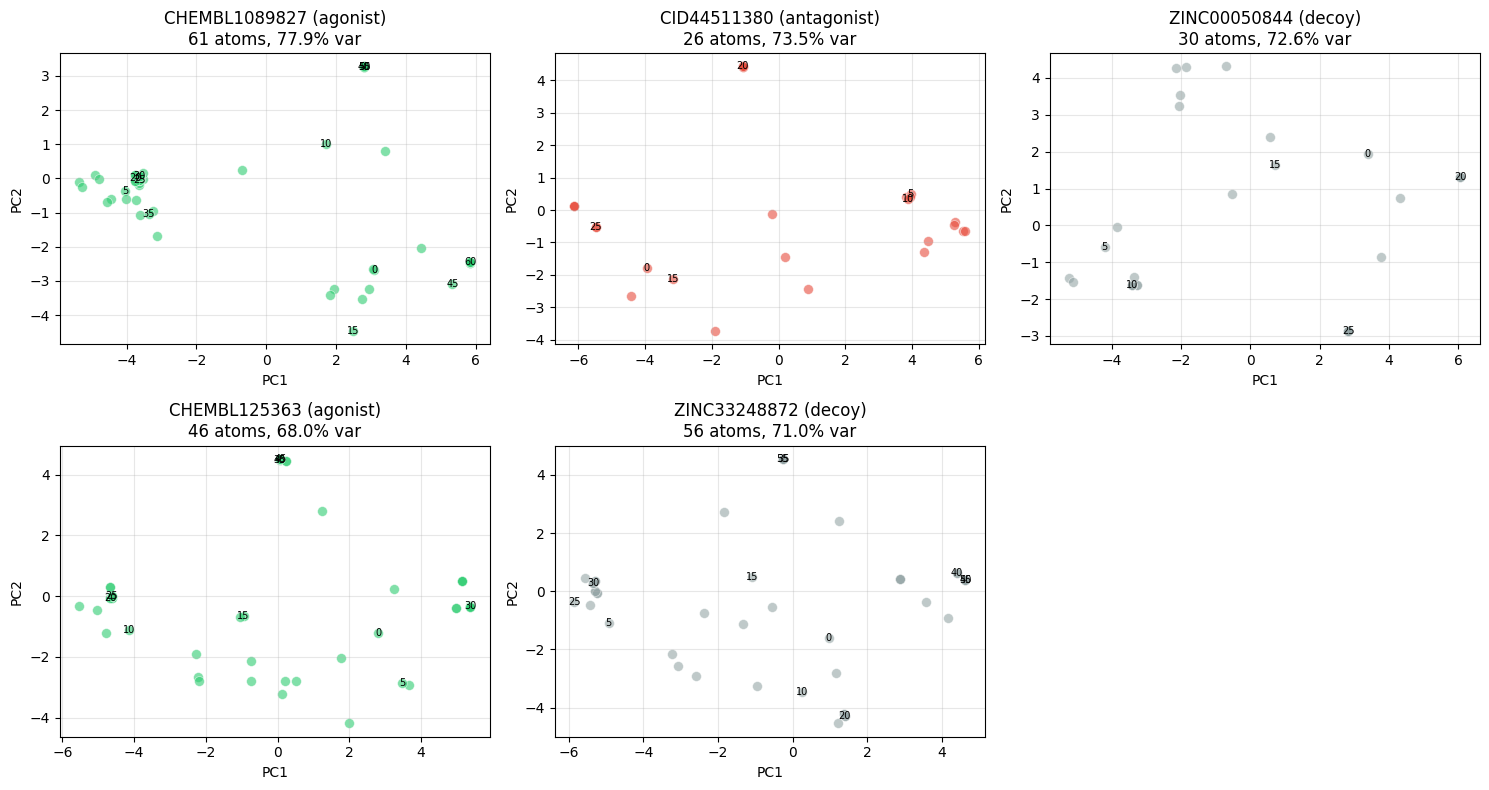

In [92]:
# Visualize per-atom embeddings
if len(atom_files) > 0:
    n_cols = min(3, len(inspect_ids))
    n_rows = int(np.ceil(len(inspect_ids) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                            figsize=(5*n_cols, 4*n_rows), dpi=DPI)
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, lig_id in enumerate(inspect_ids):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]

        # Load atom embeddings
        atom_path = ATOMS_DIR / f"{lig_id}_atoms.pt"
        if not atom_path.exists():
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(f"{lig_id}\n(no atom data)")
            continue

        h_atoms = torch.load(atom_path, map_location='cpu')
        if isinstance(h_atoms, torch.Tensor):
            h_atoms = h_atoms.detach().cpu().numpy()

        if h_atoms.shape[0] < 2:
            ax.text(0.5, 0.5, 'Too few atoms', ha='center', va='center')
            ax.set_title(f"{lig_id}\n({h_atoms.shape[0]} atoms)")
            continue

        # PCA on atom embeddings
        pca_atoms = PCA(n_components=2, random_state=RANDOM_SEED)
        h_pca = pca_atoms.fit_transform(h_atoms)

        # Get class color
        lbl = label_dict.get(lig_id, 'unknown')
        color = CLASS_COLORS.get(lbl, '#999999')

        # Plot
        ax.scatter(h_pca[:, 0], h_pca[:, 1],
                  c=color, s=50, alpha=0.6, edgecolors='white', linewidths=0.5)

        # Add atom indices
        for i, (x, y) in enumerate(h_pca):
            if i % 5 == 0:  # Label every 5th atom to avoid clutter
                ax.text(x, y, str(i), fontsize=7, ha='center', va='center')

        var_exp = pca_atoms.explained_variance_ratio_.sum()
        ax.set_title(f"{lig_id} ({lbl})\n{h_atoms.shape[0]} atoms, {var_exp*100:.1f}% var")
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(inspect_ids), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

Atom Embedding Statistics:


Analyzing:   0%|          | 0/100 [00:00<?, ?it/s]

   Atoms per ligand: 56.3 ± 12.2
   Range: [24, 83]
   Atom embedding norm: 19.016 ± 0.139


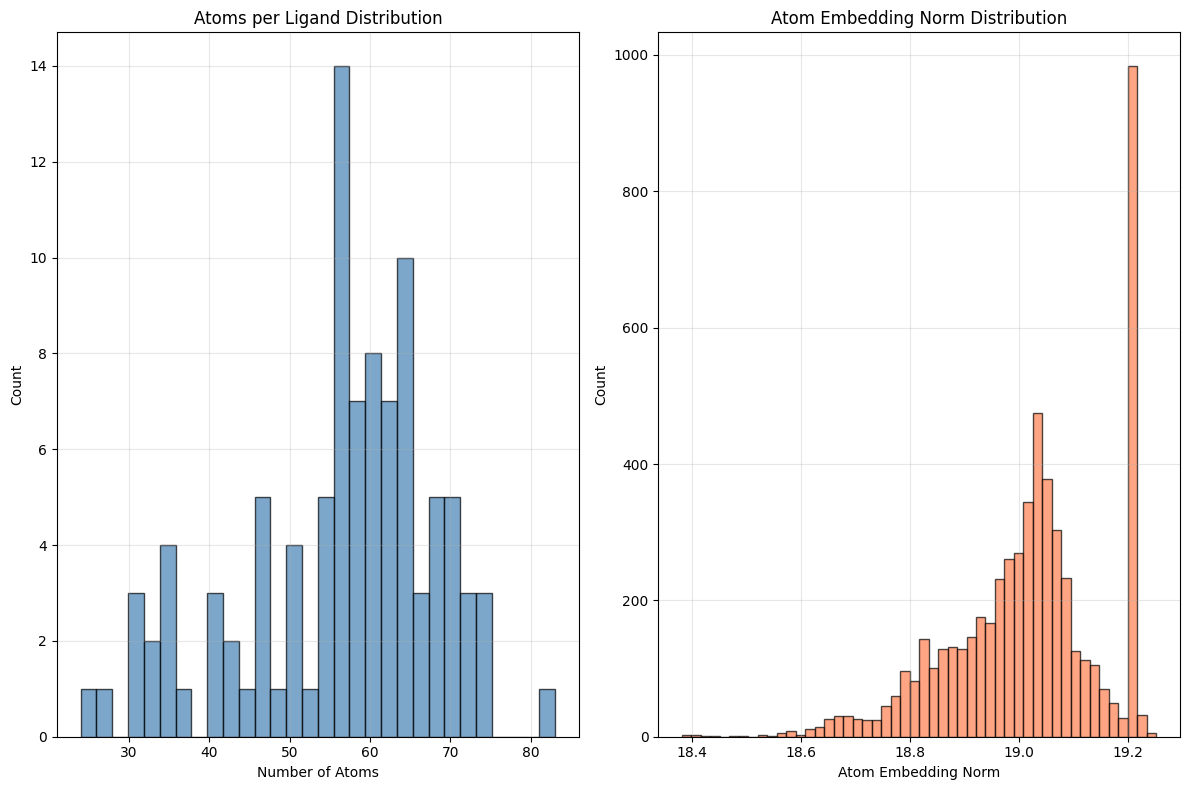

In [93]:
# Atom embedding statistics
if len(atom_files) > 0:
    print("Atom Embedding Statistics:")

    n_atoms_list = []
    atom_norms = []

    for atom_file in tqdm(atom_files[:100], desc="Analyzing"):  # Sample 100
        h_atoms = torch.load(atom_file, map_location='cpu')
        if isinstance(h_atoms, torch.Tensor):
            h_atoms = h_atoms.detach().cpu().numpy()

        n_atoms_list.append(h_atoms.shape[0])
        atom_norms.extend(np.linalg.norm(h_atoms, axis=1).tolist())

    print(f"   Atoms per ligand: {np.mean(n_atoms_list):.1f} ± {np.std(n_atoms_list):.1f}")
    print(f"   Range: [{np.min(n_atoms_list)}, {np.max(n_atoms_list)}]")
    print(f"   Atom embedding norm: {np.mean(atom_norms):.3f} ± {np.std(atom_norms):.3f}")

    # Plot distributions
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_MEDIUM, dpi=DPI)

    axes[0].hist(n_atoms_list, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Number of Atoms')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Atoms per Ligand Distribution')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(atom_norms, bins=50, alpha=0.7, color='coral', edgecolor='black')
    axes[1].set_xlabel('Atom Embedding Norm')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Atom Embedding Norm Distribution')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 4. Statistical Analysis

Embedding Quality Assessment:

1. Isotropy: 0.0054
Low isotropy (embeddings may be biased)

2. Self-Similarity:
- Mean: 0.9892
- Std: 0.0136
High self-similarity (embeddings may be collapsed)

3. Intrinsic Dimensionality:
- Dimensions for 95% variance: 13
- Efficiency: 5.1% of embedding dimensions

4. Distance Entropy: 3.0494
   (Higher entropy = more diverse pairwise distances)


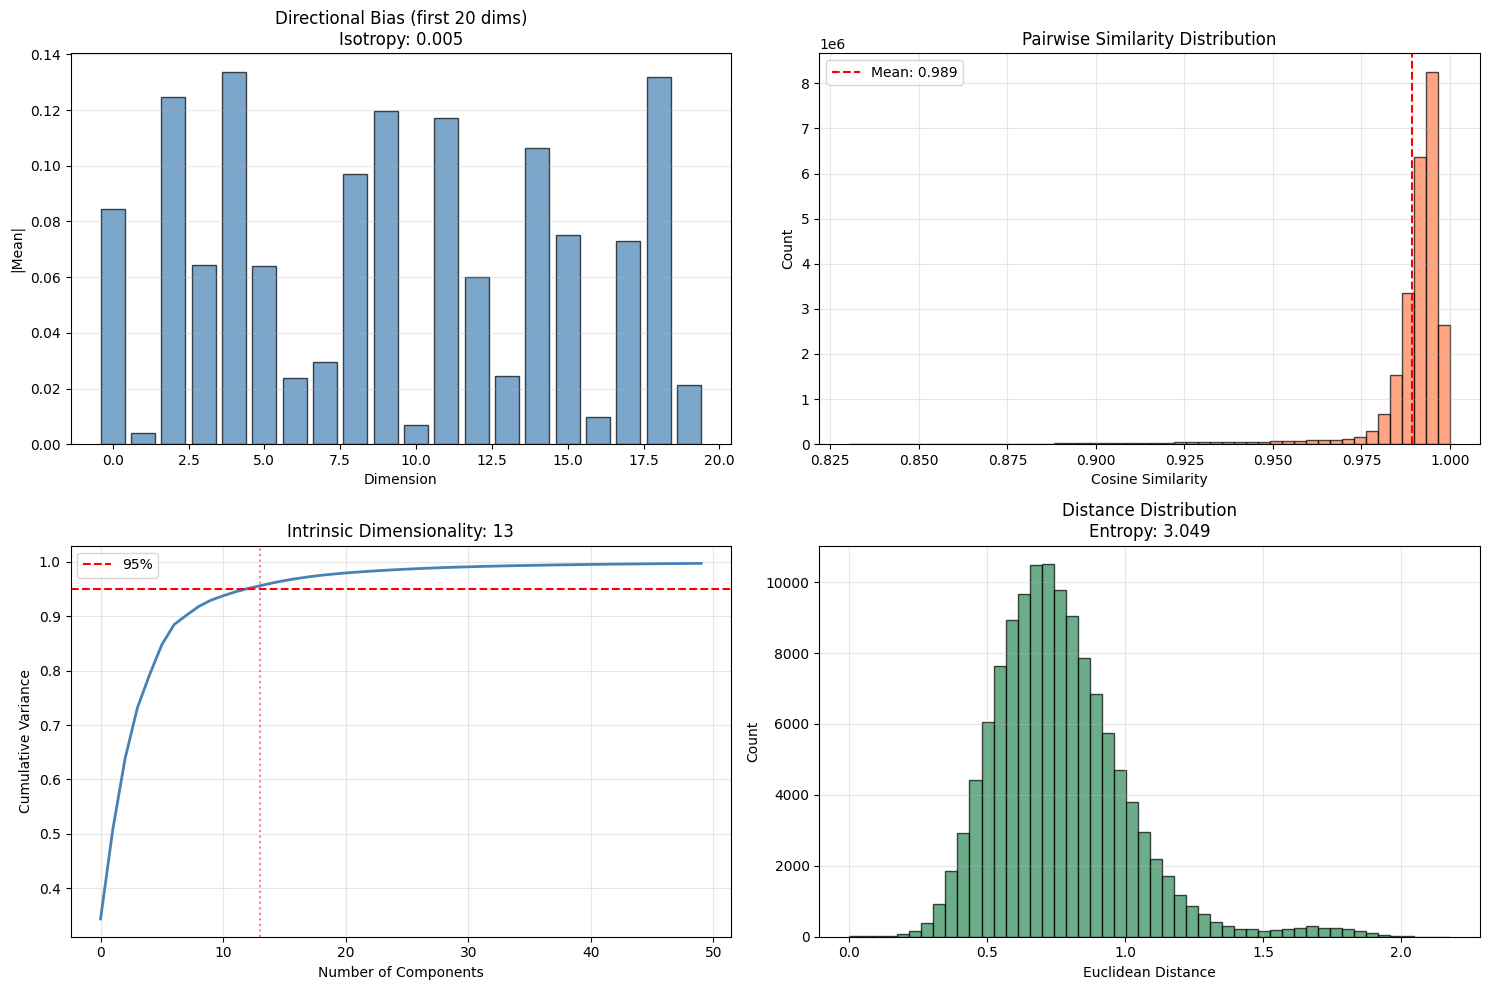

In [94]:
# Embedding quality assessment
print("Embedding Quality Assessment:")

# 1. Isotropy (how uniform is the distribution)
normalized_embs = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
mean_dir = normalized_embs.mean(axis=0)
isotropy = 1 - np.linalg.norm(mean_dir)  # Closer to 1 = more isotropic

print(f"\n1. Isotropy: {isotropy:.4f}")
if isotropy > 0.9:
    print("Highly isotropic (good)")
elif isotropy > 0.7:
    print("Moderately isotropic")
else:
    print("Low isotropy (embeddings may be biased)")

# 2. Self-similarity (check for degenerate embeddings)
cos_sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(cos_sim_matrix, np.nan)  # Exclude self-similarity
mean_self_sim = np.nanmean(cos_sim_matrix)
std_self_sim = np.nanstd(cos_sim_matrix)

print("\n2. Self-Similarity:")
print(f"- Mean: {mean_self_sim:.4f}")
print(f"- Std: {std_self_sim:.4f}")
if mean_self_sim < 0.5:
    print("Low self-similarity (good diversity)")
elif mean_self_sim < 0.7:
    print("Moderate self-similarity")
else:
    print("High self-similarity (embeddings may be collapsed)")

# 3. Dimension usage (how many dimensions are actually used)
pca_full = PCA().fit(embeddings)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
intrinsic_dim = np.argmax(cum_var >= 0.95) + 1

print("\n3. Intrinsic Dimensionality:")
print(f"- Dimensions for 95% variance: {intrinsic_dim}")
print(f"- Efficiency: {100*intrinsic_dim/embeddings.shape[1]:.1f}% of embedding dimensions")

# 4. Entropy of pairwise distances
dists = pdist(embeddings[:500], metric='euclidean')  # Sample for speed
hist, _ = np.histogram(dists, bins=50, density=True)
hist = hist[hist > 0]  # Remove zero bins
dist_entropy = entropy(hist)

print(f"\n4. Distance Entropy: {dist_entropy:.4f}")
print("   (Higher entropy = more diverse pairwise distances)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE, dpi=DPI)

# Directional bias
axes[0, 0].bar(range(len(mean_dir[:20])), np.abs(mean_dir[:20]),
              color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Dimension')
axes[0, 0].set_ylabel('|Mean|')
axes[0, 0].set_title(f'Directional Bias (first 20 dims)\nIsotropy: {isotropy:.3f}')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Self-similarity distribution
axes[0, 1].hist(cos_sim_matrix[~np.isnan(cos_sim_matrix)].flatten(),
               bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].axvline(mean_self_sim, color='red', linestyle='--',
                  label=f'Mean: {mean_self_sim:.3f}')
axes[0, 1].set_xlabel('Cosine Similarity')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Pairwise Similarity Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Explained variance
axes[1, 0].plot(cum_var[:50], linewidth=2, color='steelblue')
axes[1, 0].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1, 0].axvline(intrinsic_dim, color='red', linestyle=':', alpha=0.5)
axes[1, 0].set_xlabel('Number of Components')
axes[1, 0].set_ylabel('Cumulative Variance')
axes[1, 0].set_title(f'Intrinsic Dimensionality: {intrinsic_dim}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Distance distribution
axes[1, 1].hist(dists, bins=50, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].set_xlabel('Euclidean Distance')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'Distance Distribution\nEntropy: {dist_entropy:.3f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Agonist:
- Average 1.86/5 nearest neighbors are same class
- 37.1% class consistency
Weak class clustering

Antagonist:
- Average 0.00/5 nearest neighbors are same class
- 0.0% class consistency
Weak class clustering

Decoy:
- Average 4.85/5 nearest neighbors are same class
- 97.0% class consistency
Strong class clustering



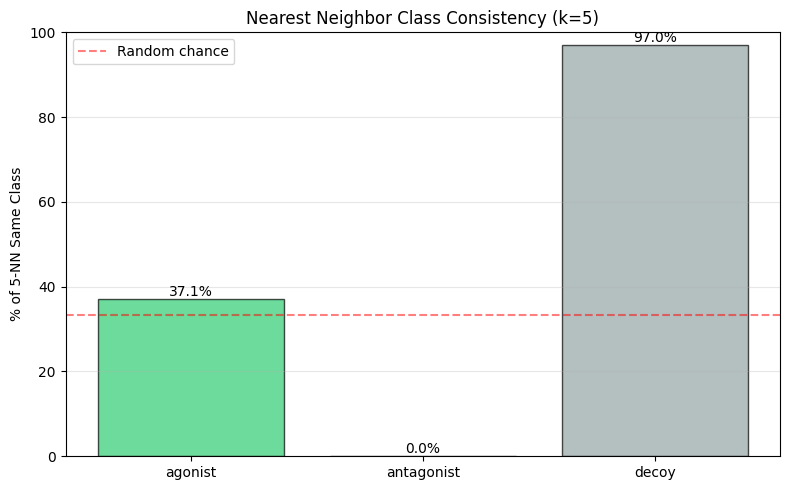

In [95]:
# Nearest neighbor analysis
# Compute cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, -np.inf)  # Exclude self

# For each ligand, find k nearest neighbors
k = 5
nn_indices = np.argsort(-sim_matrix, axis=1)[:, :k]  # Top k most similar

# Check class consistency
results = {}
for cls in ['agonist', 'antagonist', 'decoy']:
    mask = labels == cls
    if mask.sum() == 0:
        continue

    # For each ligand of this class, check NN classes
    same_class_counts = []
    for idx in np.where(mask)[0]:
        nn_labels = labels[nn_indices[idx]]
        same_class_count = (nn_labels == cls).sum()
        same_class_counts.append(same_class_count)

    avg_same = np.mean(same_class_counts)
    pct_same = 100 * avg_same / k

    results[cls] = {'avg': avg_same, 'pct': pct_same}
    print(f"{cls.capitalize()}:")
    print(f"- Average {avg_same:.2f}/{k} nearest neighbors are same class")
    print(f"- {pct_same:.1f}% class consistency")

    if pct_same > 70:
        print("Strong class clustering")
    elif pct_same > 50:
        print("Moderate class clustering")
    else:
        print("Weak class clustering")
    print()

# Visualize
if results:
    fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)

    classes = list(results.keys())
    pcts = [results[c]['pct'] for c in classes]
    colors = [CLASS_COLORS.get(c, '#999999') for c in classes]

    bars = ax.bar(classes, pcts, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(100/len(classes), color='red', linestyle='--',
              label='Random chance', alpha=0.5)
    ax.set_ylabel(f'% of {k}-NN Same Class')
    ax.set_title(f'Nearest Neighbor Class Consistency (k={k})')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()